In [106]:
import xenomorph as xm
import xenomorph.systems as wrb
import xenomorph.geometry as gm
import xenomorph.mcfost as xmc

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize

plt.rcParams.update({"text.usetex": True})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

In [76]:
system = wrb.apep.copy()

system['phase'] = 1.02
system['az_amp'] = 0
system['lum_power'] = 0.5
system['comp_reduction'] = 0
system['histmax'] = 1

system

{'m1': 15.0,
 'm2': 10.0,
 'eccentricity': 0.82,
 'inclination': 23.8,
 'asc_node': 164.1,
 'arg_peri': 10.6,
 'open_angle': 126.0,
 'period': 193.0,
 'distance': 2400.0,
 'windspeed1': 1024.0,
 'windspeed2': 2400.0,
 'turn_on': -108.0,
 'turn_off': 141.0,
 'gradual_turn': 0.1,
 'oblate': 0.0,
 'nuc_dist': 1.0,
 'opt_thin_dist': 2.0,
 'term_windspeed': 860,
 'accel_rate': -5.0,
 'orb_sd': 0.0,
 'orb_amp': 0.0,
 'orb_min': 180.0,
 'az_sd': 30.0,
 'az_amp': 0,
 'az_min': 90.0,
 'comp_incl': 124.0,
 'comp_az': 238.8,
 'comp_open': 90.0,
 'comp_reduction': 0,
 'comp_plume': 1.0,
 'comp_plume_sd': 20.0,
 'comp_plume_max': 373.0,
 'phase': 1.02,
 'sigma': 2.0,
 'histmax': 1,
 'lum_power': 0.5,
 'spin_inc': 0.0,
 'spin_Omega': 0.0,
 'windspeed_polar': 2400,
 'aniso_vel_mult': -6.2,
 'aniso_vel_power': 3.53,
 'open_angle_polar': 180.0,
 'aniso_OA_mult': -6.05,
 'aniso_OA_power': 3.53,
 'star1amp': 0.7,
 'star1sd': -0.7,
 'star2amp': 0.7,
 'star2sd': -0.7,
 'star3amp': 0.7,
 'star3sd': -1.12,
 

In [77]:
particles, weights = gm.dust_plume(system) 
n = 0.4

particles = particles[:, :int(n * particles.shape[1])]
weights = weights[:int(n * len(weights))] 
X, Y, H = gm.smooth_histogram2d(particles, weights, system)

X = system['distance'] * 206265 * np.tan(X * 4.84814e-6)
Y = system['distance'] * 206265 * np.tan(Y * 4.84814e-6)

In [100]:
masses = gm.point_cloud_dust_mass(system, 1, n_t=1000, n_points=500)

dummy_system = {'histmax': 1e20,
               'lum_power': 1.,
               'sigma': 1e-5}

masses = masses[:int(n * len(masses))] 

# Xm, Ym, Hm = gm.smooth_histogram2d(particles, masses, dummy_system)
Hm, xedges, yedges = np.histogram2d(particles[0, :], particles[1, :], bins=[X[0, :], Y[:, 0]], weights=masses)

(257, 257)


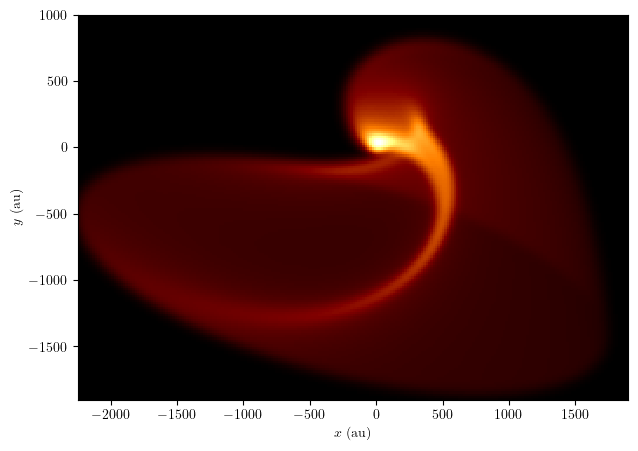

In [109]:
cmap = 'afmhot'

fig, ax = plt.subplots(figsize=(8, 5))
ax.pcolormesh(X, Y, H, cmap=cmap, rasterized=True)
ax.set(aspect='equal', ylabel='$y$ (au)', xlabel='$x$ (au)',
      ylim=(-1900, 1000), xlim=(-2250, 1900))

# vmin, vmax = np.min(Hm), np.max(Hm)
# vmin = max(1e-10, vmin)
# print(vmin, vmax)

# cmappable = ScalarMappable(LogNorm(vmin, vmax))
# cmappable.set_cmap(cmap)
# plt.colorbar(cmappable, ax=ax, label=r'Column Density (g/cm$^{2}$)', aspect=25, shrink=0.835, pad=0)

fig.savefig('Images/MRes_Plots/Apep-Geom-Model-phi-1.02.png', dpi=400, bbox_inches='tight')
fig.savefig('Images/MRes_Plots/Apep-Geom-Model-phi-1.02.pdf', dpi=400, bbox_inches='tight')